In [1]:
import cv2
import numpy as np

# make sure DPU overlay + runner are created
from pynq_dpu import DpuOverlay

overlay = DpuOverlay("dpu.bit")
overlay.load_model("tumor_net_tf2.xmodel")
dpu = overlay.runner

IMG_SIZE = 224

def preprocess_image_for_dpu(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32)

    # Inception-style preprocessing: [-1, 1]
    img = img / 127.5 - 1.0

    # Quantize to int8 (roughly)
    img_q = np.clip(img * 127.0, -128, 127).astype(np.int8)

    # Add batch dimension
    img_q = np.expand_dims(img_q, axis=0)
    return img_q

class_names = ['Glioma', 'Meningioma', 'Notumor', 'Pituitary']

def run_dpu_inference(img_path):
    img_q = preprocess_image_for_dpu(img_path)

    inp_tensors = dpu.get_input_tensors()
    out_tensors = dpu.get_output_tensors()

    # Allocate output buffer (int8)
    output_data = [np.empty(out_tensors[0].dims, dtype=np.int8)]

    # Run on DPU
    job_id = dpu.execute_async([img_q], output_data)
    dpu.wait(job_id)

    logits_int8 = output_data[0].reshape(-1)  # shape (4,)

    pred_idx = int(np.argmax(logits_int8))
    pred_label = class_names[pred_idx]

    return pred_idx, pred_label, logits_int8


/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/ps.py:434: UserWarning: Setting frequency to the closest possible value 98.8879MHz.
  warnings.warn(


In [2]:
import os
from collections import Counter

# Adjusted root path (based on your screenshot)
test_root = "/home/xilinx/jupyter_notebooks/test"

# Folder names on disk (lowercase)
folder_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Logical class names we’ll report
class_names = ['Glioma', 'Meningioma', 'Notumor', 'Pituitary']
folder_to_class = dict(zip(folder_names, class_names))

max_total = 20      # total images across all classes
y_true = []
y_pred = []
used_paths = []

candidates = []
for folder, cls_name in folder_to_class.items():
    cls_dir = os.path.join(test_root, folder)
    if not os.path.isdir(cls_dir):
        print(f"Warning: folder not found: {cls_dir}")
        continue
    for fname in os.listdir(cls_dir):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        candidates.append((cls_name, os.path.join(cls_dir, fname)))

# Take up to 20 images
candidates = candidates[:max_total]

print(f"Running DPU inference on {len(candidates)} labeled images from {test_root}...\n")

for true_cls, path in candidates:
    pred_idx, pred_label, logits = run_dpu_inference(path)
    y_true.append(true_cls)
    y_pred.append(pred_label)
    used_paths.append(path)
    print(f"{os.path.basename(path)} | TRUE: {true_cls:10s} | PRED: {pred_label:10s} | logits: {logits}")

# Overall accuracy
correct = sum(t == p for t, p in zip(y_true, y_pred))
total = len(y_true)
acc = correct / total if total > 0 else 0.0
print(f"\nDPU accuracy on these {total} images: {acc*100:.2f}% ({correct}/{total})")

# Per-class summary
print("\nPer-class prediction counts (TRUE -> predicted labels):")
summary = {}
for t, p in zip(y_true, y_pred):
    summary.setdefault(t, []).append(p)

for cls in class_names:
    if cls not in summary:
        continue
    counts = Counter(summary[cls])
    print(f"{cls}: {dict(counts)}")


Running DPU inference on 20 labeled images from /home/xilinx/jupyter_notebooks/test...

brisc2025_test_00012_gl_ax_t1.jpg | TRUE: Glioma     | PRED: Glioma     | logits: [ 42 -12 -12  -7]
brisc2025_test_00007_gl_ax_t1.jpg | TRUE: Glioma     | PRED: Glioma     | logits: [ 24 -15  -8  22]
brisc2025_test_00011_gl_ax_t1.jpg | TRUE: Glioma     | PRED: Pituitary  | logits: [-1  0  2 29]
brisc2025_test_00010_gl_ax_t1.jpg | TRUE: Glioma     | PRED: Pituitary  | logits: [ 3 -8  0 43]
brisc2025_test_00001_gl_ax_t1.jpg | TRUE: Glioma     | PRED: Glioma     | logits: [ 38 -16  -9   1]
brisc2025_test_00421_me_co_t1.jpg | TRUE: Meningioma | PRED: Notumor    | logits: [-3  8 11 -3]
brisc2025_test_00313_me_ax_t1.jpg | TRUE: Meningioma | PRED: Notumor    | logits: [-10  10  25  -1]
brisc2025_test_00556_me_sa_t1.jpg | TRUE: Meningioma | PRED: Meningioma | logits: [ -1  27 -10   5]
brisc2025_test_00484_me_sa_t1.jpg | TRUE: Meningioma | PRED: Meningioma | logits: [ 3 11 -3  1]
brisc2025_test_00420_me_co_t

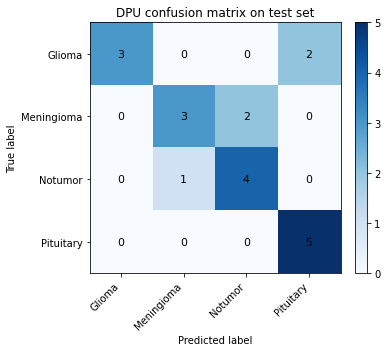

In [3]:
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(class_names)
cm = np.zeros((num_classes, num_classes), dtype=int)
name_to_idx = {name: i for i, name in enumerate(class_names)}

for t, p in zip(y_true, y_pred):
    i = name_to_idx[t]
    j = name_to_idx[p]
    cm[i, j] += 1

fig, ax = plt.subplots(figsize=(6, 5))  # bigger figure
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')  # higher-contrast colormap

# ticks & labels
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("DPU confusion matrix on test set")

# annotate counts
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", color="black", fontsize=11)

# add colorbar
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Per-class accuracy:
Glioma: 60.0% (3/5)
Meningioma: 60.0% (3/5)
Notumor: 80.0% (4/5)
Pituitary: 100.0% (5/5)


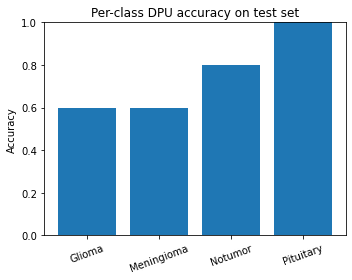

In [4]:
import matplotlib.pyplot as plt
import numpy as np

correct_per_class = np.zeros(num_classes, dtype=int)
total_per_class = np.zeros(num_classes, dtype=int)

for t, p in zip(y_true, y_pred):
    i = name_to_idx[t]
    total_per_class[i] += 1
    if t == p:
        correct_per_class[i] += 1

acc_per_class = correct_per_class / np.maximum(total_per_class, 1)

print("Per-class accuracy:")
for name, acc, c, tot in zip(class_names, acc_per_class, correct_per_class, total_per_class):
    print(f"{name}: {acc*100:.1f}% ({c}/{tot})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_names, acc_per_class)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Per-class DPU accuracy on test set")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [5]:
correct = sum(t == p for t, p in zip(y_true, y_pred))
total = len(y_true)
overall_acc = correct / total if total > 0 else 0.0
print(f"Overall DPU accuracy on test set: {overall_acc*100:.2f}% ({correct}/{total})")


Overall DPU accuracy on test set: 75.00% (15/20)
